# Mensch ärgere Dich nicht — strategy research

Simulating many automated 4-player games to study:

1. average **game length**,
2. **win rates** per strategy — in particular **mean vs. nice**,
3. **first-player / seat advantage** (for every strategy),
4. whether the **`optimal`** strategy (from a published strategy guide) beats pure aggression,
5. **why `random` is so weak** — the role of move efficiency,
6. supporting effects: aggression vs. success.

All heavy lifting lives in the `maedn` package; this notebook only makes high-level calls and plots.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # import maedn from the repo root

import pandas as pd
import matplotlib.pyplot as plt

from maedn import run_tournament, STRATEGIES
from maedn import analysis

ALL_STRATEGIES = sorted(STRATEGIES)
print('available strategies:', ALL_STRATEGIES)

available strategies: ['defensive', 'mean', 'nice', 'optimal', 'random', 'runahead']


## Configuration

In [2]:
SEATS = ['mean', 'nice', 'random', 'defensive']  # one strategy per seat
N_GAMES = 5000
SEED = 42

df = run_tournament(SEATS, n_games=N_GAMES, seed=SEED, rotate_seats=True)
df.head()

,game,turns,rolls,hit_turn_cap,winner_seat,winner_strategy,seat_0,made_0,suffered_0,seat_1,made_1,suffered_1,seat_2,made_2,suffered_2,seat_3,made_3,suffered_3
0,0,275,324,False,2,random,mean,8,7,nice,5,8,random,3,3,defensive,6,4
1,1,374,448,False,1,random,nice,7,8,random,10,9,defensive,10,7,mean,8,11
2,2,200,234,False,3,nice,random,3,3,defensive,1,1,mean,4,4,nice,1,1
3,3,343,413,False,2,nice,defensive,5,7,mean,9,6,nice,5,4,random,4,6
4,4,353,438,False,0,mean,mean,13,6,nice,2,13,random,9,9,defensive,13,9


## 1. Game length

count    5000.000000
mean      305.874800
std        70.045494
min       130.000000
25%       256.000000
50%       299.000000
75%       349.000000
max       626.000000
Name: turns, dtype: float64


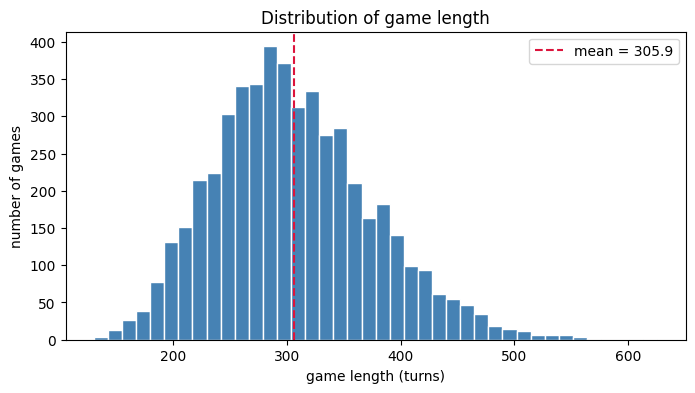

In [3]:
print(analysis.game_length_stats(df))
fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_length_hist(df, ax=ax)
plt.show()

## 2. Win rate per strategy

strategy
mean         0.4786
nice         0.2568
defensive    0.1440
random       0.1206
Name: is_winner, dtype: float64


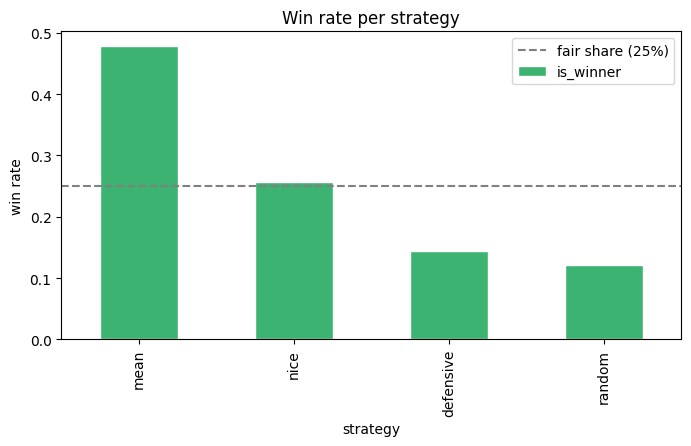

In [4]:
print(analysis.win_rates(df))
fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_win_rates(df, ax=ax)
plt.show()

## 3. Mean vs. Nice

The headline question: does aggression pay off?

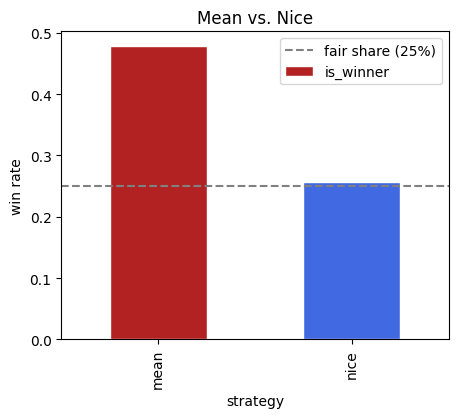

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
analysis.plot_mean_vs_nice(df, ax=ax)
plt.show()

## 4. Aggression vs. success

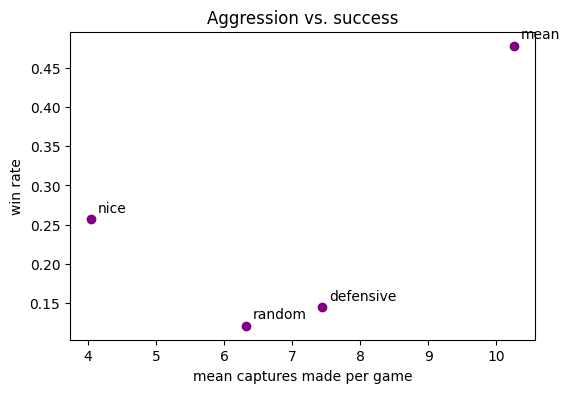

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
analysis.plot_captures_vs_winrate(df, ax=ax)
plt.show()

## 5. Does the first player have an advantage? (every strategy)

Seat 0 plays first. To isolate the **pure turn-order effect** we let all four seats use the *same*
strategy — then any win-rate difference between seats is positional, not a strategy artefact. We
repeat this controlled experiment for **every** strategy.

`seat_advantage` gives per-seat win rates with 95% confidence intervals; `seat_uniformity_test` runs a
chi-square test of whether the seat differences exceed chance (`significant=True` ⇒ turn order
matters for that strategy).

In [7]:
FPA_GAMES = 20000

# Run each controlled experiment once and reuse it for the table and the plots.
experiments = {
    s: analysis.first_player_experiment(strategy=s, n_games=FPA_GAMES, seed=0)
    for s in ALL_STRATEGIES
}

In [8]:
# Summary table: per-seat win rate + chi-square test, one row per strategy.
rows = {}
for s, exp in experiments.items():
    adv = analysis.seat_advantage(exp)['win_rate']
    test = analysis.seat_uniformity_test(exp)
    row = {f'seat_{seat}': adv[seat] for seat in adv.index}
    row['first_minus_last'] = adv.iloc[0] - adv.iloc[-1]
    row['chi2'] = test['chi2']
    row['significant'] = test['significant']
    rows[s] = row

summary = pd.DataFrame(rows).T
summary.round(4)

,seat_0,seat_1,seat_2,seat_3,first_minus_last,chi2,significant
defensive,0.25665,0.2497,0.24655,0.2471,0.00955,5.17,False
mean,0.25675,0.25095,0.24885,0.24345,0.0133,7.2552,False
nice,0.2609,0.2473,0.24855,0.24325,0.01765,13.9012,True
optimal,0.253,0.2521,0.2463,0.2486,0.0044,2.3248,False
random,0.2499,0.24895,0.2527,0.24845,0.00145,0.8644,False
runahead,0.25905,0.2521,0.24425,0.2446,0.01445,11.8828,True


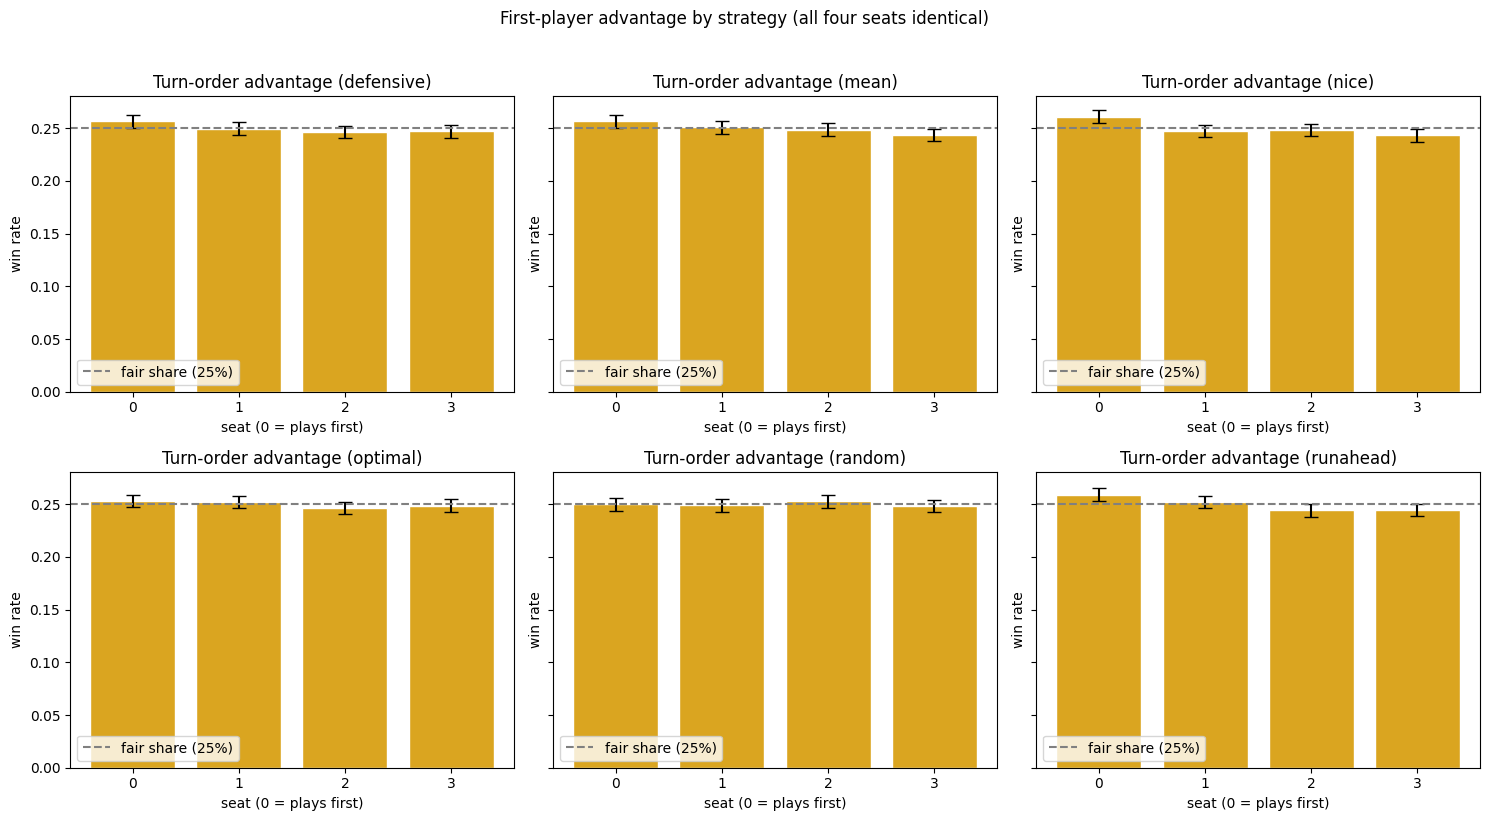

In [9]:
# One seat-advantage bar chart (with 95% CIs) per strategy.
ncols = 3
nrows = -(-len(ALL_STRATEGIES) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
for ax, s in zip(axes.flat, ALL_STRATEGIES):
    analysis.plot_seat_advantage(experiments[s], ax=ax)
    ax.set_title(f'Turn-order advantage ({s})')
for ax in axes.flat[len(ALL_STRATEGIES):]:
    ax.axis('off')  # hide unused panels
fig.suptitle('First-player advantage by strategy (all four seats identical)', y=1.02)
plt.tight_layout()
plt.show()

## 6. How good is the published 'optimal' strategy?

`optimal` follows the actionable advice from a bayern3.de strategy guide: **capture whenever
possible**, **keep a >6-field safety lead** (rescue figures that fall into reach), and **race the
leading figure** rather than bunching figures together. Does following the guide beat the
single-minded `mean`? We pit it against a mixed field and then head-to-head against three `mean`
players.

4-way win rates:
strategy
mean       0.401
optimal    0.301
nice       0.201
random     0.096
Name: is_winner, dtype: float64



optimal vs three mean:
strategy
mean       0.266
optimal    0.202
Name: is_winner, dtype: float64


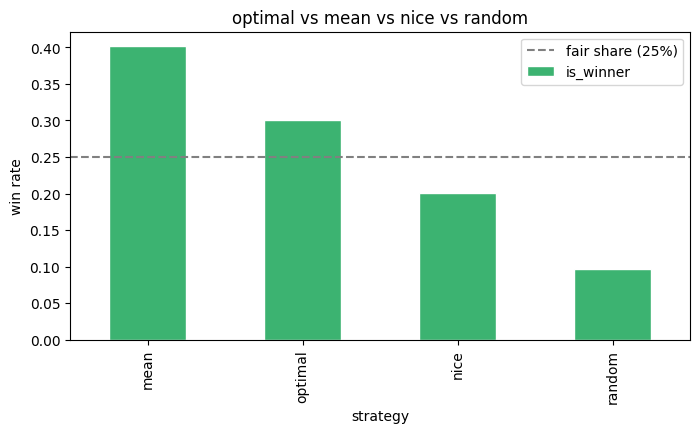

In [10]:
df_opt = run_tournament(['optimal', 'mean', 'nice', 'random'], n_games=5000, seed=42)
print('4-way win rates:')
print(analysis.win_rates(df_opt).round(3))

df_h2h = run_tournament(['optimal', 'mean', 'mean', 'mean'], n_games=5000, seed=7)
print('\noptimal vs three mean:')
print(analysis.win_rates(df_h2h).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
analysis.plot_win_rates(df_opt, ax=ax)
ax.set_title('optimal vs mean vs nice vs random')
plt.show()

**Result:** the guide's tactics are strong — `optimal` is the **second-best** strategy, far ahead of
the timid `nice`/`random`/`defensive` play, which validates its core advice (capture + race your
leader). But pure unconditional `mean` still **edges it head-to-head**: the guide's defensive
refinements (keeping a safety lead) cost a little tempo in a game dominated by luck. Both agree that
**racing the leading figure beats spreading out**.

## 7. Why is `random` so weak?

`random` is by far the worst strategy — e.g. `nice` beats it handily. It is tempting to think `random`
loses because it is not aggressive, but the opposite is true: it captures *more* than `nice` and still
loses. The real driver is **move efficiency**.

Every strategy only chooses among the *free* legal moves (forced enter-on-6 / vacate-A moves are
applied upstream). `nice`, despite its name, breaks ties by **landing the furthest** — so it keeps
racing its lead figure forward and banking figures into the safe goal lane. `random` has no such
preference and scatters its progress.

In [11]:
# (a) random captures MORE than nice, yet loses -> capturing is not the driver.
df_nr = run_tournament(['nice', 'random', 'nice', 'random'], n_games=8000, seed=3)
print('nice vs random (2v2) win rates:')
print(analysis.win_rates(df_nr).round(3))
print('\ncaptures made / suffered per strategy:')
print(analysis.captures_by_strategy(df_nr).round(2))

nice vs random (2v2) win rates:
strategy
nice      0.321
random    0.179
Name: is_winner, dtype: float64

captures made / suffered per strategy:
          made  suffered
strategy                
nice      4.64      5.64
random    7.11      6.12


random      0.250
nice        0.389
runahead    0.503
mean        0.584


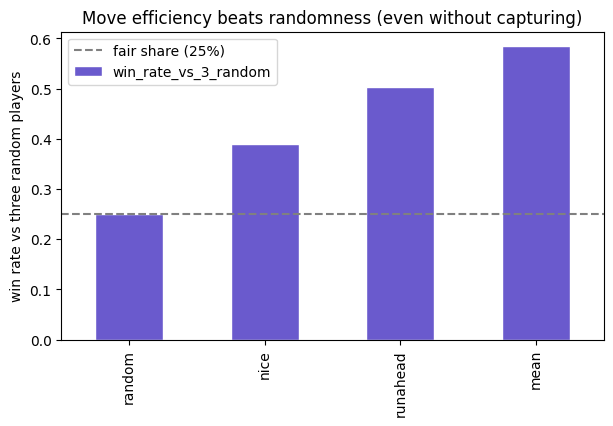

In [12]:
# (b) Isolate efficiency: how strategies fare against three random players.
#     runahead ignores capturing entirely, yet still doubles random's win rate.
challengers = ['random', 'nice', 'runahead', 'mean']
vs_random = {}
for a in challengers:
    d = run_tournament([a, 'random', 'random', 'random'], n_games=8000, seed=5)
    vs_random[a] = analysis.win_rates(d)[a]
vs_random = pd.Series(vs_random, name='win_rate_vs_3_random')
print(vs_random.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
vs_random.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.axhline(1 / 4, color='grey', linestyle='--', label='fair share (25%)')
ax.set_ylabel('win rate vs three random players')
ax.set_title('Move efficiency beats randomness (even without capturing)')
ax.legend()
plt.show()

**Result:** `random` captures *more* than `nice` but still loses, so aggression is not the issue.
Against three `random` players, even the capture-ignoring `runahead` wins ~50% (double its fair
share) purely by advancing efficiently. `random` is weak because it (1) fails to bank figures into
the permanently-safe goal lane, (2) wastes the narrow exact-roll chances to finish a figure, and
(3) scatters its pips instead of compounding them on a figure that is actually crossing the finish —
leaving figures loitering on the track where one capture undoes ~40 fields of progress.

## 8. Try your own match-ups

Each seat is independent, so any mix works — e.g. a 2-vs-2 mean/nice study, or one aggressor against three pacifists.

In [13]:
df_2v2 = run_tournament(['mean', 'mean', 'nice', 'nice'], n_games=5000, seed=1)
print(analysis.win_rates(df_2v2))
print('avg game length:', df_2v2['turns'].mean())

strategy
mean    0.3414
nice    0.1586
Name: is_winner, dtype: float64
avg game length: 285.8036
